# Overcome complex terrain with a hybrid controller (FlyGym v2)

**Authors:** Victor Alfred Stimpfling, Sibo Wang-Chen

**Note:** The code presented in this notebook has been simplified and restructured for display in a notebook format. A more complete and better structured implementation can be found in the [examples folder of the FlyGym repository on GitHub](https://github.com/NeLy-EPFL/flygym/tree/main/flygym/examples/).

**Summary**: In this tutorial, we will illustrate how CPG- and rule-based controllers fail to produce robust locomotion over complex terrain. We will then build a combined CPG and sensory feedback-based hybrid controller that overcomes these deficits and generates more robust walking.

In the *[Controlling locomotion with CPGs](https://neuromechfly.org/tutorials/cpg_controller.html)* and *[Rule-based controller](https://neuromechfly.org/tutorials/rule_based_controller.html)* tutorials, we have demonstrated how different control strategies can lead to effective walking over simple, flat terrain. However, in the real world animals locomote over rugged surfaces. To achieve this, animals likely use a combination of CPGs and sensory feedback to produce agile, adaptive body kinematics. To explore how sensory feedback can facilitate locomotion over rugged surfaces, we have developed three terrain types that complement our baseline smooth terrain: one with gaps perpendicular to the initial heading of the fly, one with blocks of variable height, and one that is a mixture of these two. Using these new terrain types, we will now demonstrate how one can examine the efficacy of different bioinspired locomotor control strategies.

**FlyGym v2:** executable cells use `flygym.Simulation`, `flygym_demo.examples.worlds` terrain worlds, `CPGController`, `RuleBasedController`, `HybridController`, and `run_closed_loop` instead of `flygym_gymnasium` / Gymnasium environments.


## Defining the arena

The environment that the fly is situated in is defined by the Arena class. So far, we have been using the default terrain: ``FlatTerrain``. Some other arenas are also included in FlyGym package, including ``GappedTerrain``, ``BlocksTerrain``, and ``MixedTerrain``. In future tutorials, we will introduce more arenas with sensory (visual, olfactory) features. The user can define custom arenas by inheriting from the ``flygym.mujoco.arena.BaseArena`` abstract class.

Let's start by defining a couple of terrains:

In [1]:
from flygym_demo.examples.worlds.terrain import (
    FlatDemoWorld,
    GappedTerrainWorld,
    BlocksTerrainWorld,
    MixedTerrainWorld,
)


def get_arena(arena_type):
    if arena_type == "flat":
        return FlatDemoWorld()
    elif arena_type == "gapped":
        return GappedTerrainWorld()
    elif arena_type == "blocks":
        return BlocksTerrainWorld()
    elif arena_type == "mixed":
        return MixedTerrainWorld()
    else:
        raise ValueError(f"Unknown arena type: {arena_type}")


Let's put a fly into each of these terrains, run 0.01 seconds of the simulation so the fly can stabilize on the floor, and visualize how the fly looks while walking over these different terrain types:

/home/user/flygym/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
terrain previews:   0%|          | 0/4 [00:00<?, ?it/s]


ValueError: Expected 42 inputs for actuator type 'POSITION', but got 66

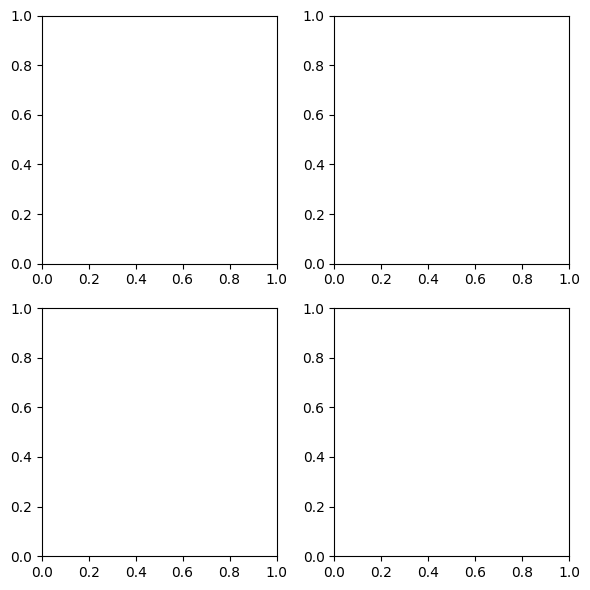

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path

from flygym import Simulation
from flygym.anatomy import ContactBodiesPreset
from flygym.compose import ActuatorType
from flygym.utils.math import Rotation3D
from flygym_demo.examples import make_walking_fly
from flygym_demo.examples.locomotion import PreprogrammedSteps

output_dir = Path("outputs/hybrid_controller")
output_dir.mkdir(exist_ok=True, parents=True)

preprogrammed_steps = PreprogrammedSteps()

fig, axs = plt.subplots(2, 2, figsize=(6, 6), tight_layout=True)
terrain_types = ["flat", "gapped", "blocks", "mixed"]
for i, terrain_type in tqdm(list(enumerate(terrain_types)), desc="terrain previews"):
    ax = axs.flat[i]
    world = get_arena(terrain_type)
    fly = make_walking_fly(add_camera=True)
    world.add_fly(
        fly,
        spawn_position=[0, 0, 0.5],
        spawn_rotation=Rotation3D("quat", [1, 0, 0, 0]),
        bodysegs_with_ground_contact=ContactBodiesPreset.TIBIA_TARSUS_ONLY,
        add_ground_contact_sensors=True,
    )
    sim = Simulation(world)
    jointdof_order = fly.get_jointdofs_order()
    actuated_order = fly.get_actuated_jointdofs_order(ActuatorType.POSITION)
    actuated_idx = np.array(
        [jointdof_order.index(d) for d in actuated_order], dtype=np.intp
    )
    trackcam = fly.cameraname_to_mjcfcamera["trackcam"]
    sim.set_renderer(trackcam, camera_res=(240, 320), playback_speed=0.1, output_fps=25)
    sim.reset()
    neutral = sim.get_joint_angles(fly.name)[actuated_idx].copy()
    for _ in range(100):
        sim.set_actuator_inputs(fly.name, ActuatorType.POSITION, neutral)
        sim.set_leg_adhesion_states(fly.name, np.ones(6, dtype=np.float32))
        sim.step()
        sim.render_as_needed()
    cam_name = next(iter(sim.renderer.frames.keys()))
    ax.imshow(sim.renderer.frames[cam_name][-1])
    ax.axis("off")
    ax.set_title(f"{terrain_type.title()} terrain")

fig.savefig(output_dir / "complex_terrain_overview.png")


## Basic CPG- and rule-based controllers

Do the CPG- and rule-based controllers work well over complex terrain? Let's run the simulation for 0.5 seconds using each of these controllers on each of the different terrain types:

In [ ]:
from flygym import Simulation
from flygym.anatomy import ContactBodiesPreset
from flygym.compose import ActuatorType
from flygym.utils.math import Rotation3D
from flygym_demo.examples import make_walking_fly, run_closed_loop
from flygym_demo.examples.locomotion import (
    PreprogrammedSteps,
    RuleBasedController,
    construct_rules_graph,
)
from flygym_demo.examples.locomotion.cpg_controller import CPGController

run_time = 1.0
timestep = 1e-4

for controller_name in ["CPG-based", "Rule-based"]:
    for terrain_name in terrain_types:
        print(f"* Running {controller_name} controller on {terrain_name} terrain")

        world = get_arena(terrain_name)
        fly = make_walking_fly(add_camera=True)
        world.add_fly(
            fly,
            spawn_position=[0, 0, 0.5],
            spawn_rotation=Rotation3D("quat", [1, 0, 0, 0]),
            bodysegs_with_ground_contact=ContactBodiesPreset.TIBIA_TARSUS_ONLY,
            add_ground_contact_sensors=True,
        )
        sim = Simulation(world)
        trackcam = fly.cameraname_to_mjcfcamera["trackcam"]
        sim.set_renderer(trackcam, camera_res=(240, 320), playback_speed=0.1, output_fps=25)

        preprogrammed_steps = PreprogrammedSteps()
        try:
            if controller_name == "CPG-based":
                controller = CPGController(sim.timestep, preprogrammed_steps=preprogrammed_steps)
            elif controller_name == "Rule-based":
                weights = {
                    "rule1": -10,
                    "rule2_ipsi": 2.5,
                    "rule2_contra": 1,
                    "rule3_ipsi": 3.0,
                    "rule3_contra": 2.0,
                }
                rules_graph = construct_rules_graph()
                controller = RuleBasedController(
                    timestep=sim.timestep,
                    rules_graph=rules_graph,
                    weights=weights,
                    preprogrammed_steps=preprogrammed_steps,
                )
            else:
                raise ValueError(f"Unknown controller: {controller_name}")

            records = run_closed_loop(
                sim,
                controller,
                run_time,
                fly_name=fly.name,
                render=True,
                warmup_s=0.1,
            )
        except Exception as e:
            print(f"Simulation failed with error: {e}")
            continue

        thorax_i = fly.get_bodysegs_order().index(fly.root_segment)
        x_pos = records[-1]["body_positions"][thorax_i, 0]
        print(f"Final x position: {x_pos:.4f} mm")

        tag = controller_name.replace("-", "_").replace(" ", "_")
        sim.renderer.save_video(output_dir / f"{tag}_{terrain_name}.mp4")


* Running CPG-based controller on flat terrain


100%|██████████| 10000/10000 [00:36<00:00, 272.59it/s]


Final x position: 13.8071 mm
* Running CPG-based controller on gapped terrain


 49%|████▉     | 4885/10000 [00:41<00:50, 101.84it/s]

Though we have only tested one initial condition (spawn position, controller) per case, we can already begin to observe that the CPG- and rule-based controllers may not perform robustly over complex terrain. In fact, if we run 20 initial conditions for 1 second each, we get a result like the one reported in the NeuroMechFly v2 paper (Wang-Chen et al., 2024):

<img src="https://github.com/NeLy-EPFL/_media/blob/main/flygym/hybrid_controller/cpg_rule_based_comparison.png?raw=true" alt="cpg_rule_based_comparison" width="800"/>

We can look more closely at some examples of failed locomotion:

*CPG-based controller over gapped terrain:*

<video width="400" controls>
  <source src="https://raw.githubusercontent.com/NeLy-EPFL/_media/main/flygym/hybrid_controller/CPG-based_gapped.mp4" type="video/mp4">
</video>

*Rule-based controller over gapped terrain:*

<video width="400" controls>
  <source src="https://raw.githubusercontent.com/NeLy-EPFL/_media/main/flygym/hybrid_controller/Rule-based_gapped.mp4" type="video/mp4">
</video>

In the next section, we will show how, by combining CPGs with sensory feedback, we can build a more robust "hybrid" controller.

## Building a hybrid controller

Now, we will build a hybrid controller that integrates both CPG-like oscillators and sensory feedback-based rules that reposition the legs when they get stuck. As described in the NeuroMechFly v2 paper, we will detect the following conditions:

1. **Retraction:** In principle, with the tripod gait, there should always be three legs on the ground. Therefore, if any leg is extended farther than the third most extended leg in the z-direction (height), this leg may be stuck in a hole. This rule will lift the leg to recover it from a stuck position.
2. **Stumbling:** In principle, only the tip of the tarsus of each leg should contact with the ground. Therefore, we will consider the fly to be stumbling if the tibia or upper tarsal segments (1 and 2) collide with terrain resulting in a supra-threshold force against the direction of the fly’s heading. To correct for stumbling we will lift the stumbling leg.

To implement these rules, we will create a variable for each rule that keeps track of the extent to which a given leg should be lifted:

In [ ]:
retraction_correction = np.zeros(6)
stumbling_correction = np.zeros(6)

retraction_persistence_counter = np.zeros(6)

We will also define a vector representing how each DoF should be adjusted to implement leg lifting. We will call this $\vec{v}_\text{leg}$.

In [ ]:
correction_vectors = {
    # leg group (front / middle / hind): same rad offsets as the FlyGym 1.x notebook
    "f": np.array([-0.03, 0, 0, -0.03, 0, 0.03, 0.03]),
    "m": np.array([-0.015, 0.001, 0.025, -0.02, 0, -0.02, 0.0]),
    "h": np.array([0, 0, 0, -0.02, 0, 0.01, -0.02]),
}


That is, when the leg should be lifted, we will increment the joint angles on this leg by $\vec{v}_\text{leg}$ scaled by a factor defining the extent of correction. When the condition is no longer met, we will reduce the correction term until it reaches zero (i.e., with no adjustment) so that the target angles applied to the simulator are those suggested by the corresponding CPGs.

Next, we need to define the factor dictating the extent of correction. Recall that we will progressively lift the leg when an adjustment is necessary. Therefore, let's also define the rate of adjustment $k_\text{inc}$ when the condition is met and the rate of recovery $k_\text{dec}$ when the condition is no longer met:

In [ ]:
correction_rates = {
    # (increment rate, decrement rate), units 1/s — passed to `HybridController`
    "retraction": (800.0, 700.0),
    "stumbling": (2200.0, 1800.0),
}


Concretely, we will initialize the amount of correction $c$ to 0. This variable is unitless. For every $t$ amount of time that the condition is met, we increment $c$ by $k_\text{inc}t$ where $k_\text{inc}$ is the appropriate correction rate. Similarly, for every $t$ amount of time that the condition is no longer met, we will decrement $c$ by $k_\text{dec}t$ until it reaches 0. We will therefore adjust the leg joint angles by adding $c\vec{v}_\text{leg}$ to it.

We should also define a threshold for the stumbling force. Note that a negative number indicates a force against the direction in which the fly is facing:

In [ ]:
stumbling_force_threshold = -1

Next, we will define the underlying CPG network as we did in the [tutorial on CPG-based control](https://neuromechfly.org/tutorials/cpg_controller.html):

In [ ]:
run_time = 1
timestep = 1e-4

# The runnable hybrid controller below uses `HybridController` from `flygym_demo`, which
# owns the CPG network and correction state (no separate `CPGNetwork` object needed here).


Similarly, let's define the preprogrammed steps:

In [ ]:
# Initialize preprogrammed steps
preprogrammed_steps = PreprogrammedSteps()

In our hybrid controller the action performed by a leg stuck in a hole or colliding with an edge depends on the stepping phase. Upon on activating one of the rules, when the leg is in stance and adhesion is on, the leg can be slightly more extended to allow the other legs to overcome an obstacle. When the leg is in swing and one of the legs is active, the leg can be retracted higher to help overcome the obstacle. Here we define the phasic gain that will help to implement this behavior.

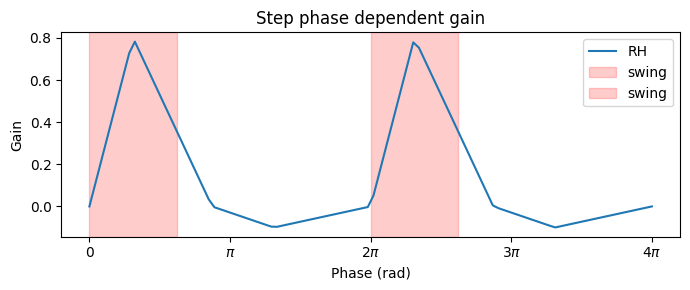

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

step_phase_gain = {}

for leg in preprogrammed_steps.legs:
    swing_start, swing_end = preprogrammed_steps.swing_period[leg]

    step_points = [
        swing_start,
        np.mean([swing_start, swing_end]),
        swing_end + np.pi / 4,
        np.mean([swing_end, 2 * np.pi]),
        2 * np.pi,
    ]
    preprogrammed_steps.swing_period[leg] = (swing_start, swing_end + np.pi / 4)
    increment_vals = [0, 0.8, 0, -0.1, 0]

    step_phase_gain[leg] = interp1d(
        step_points, increment_vals, kind="linear", fill_value="extrapolate"
    )

fig = plt.figure(figsize=(7, 3), tight_layout=True)
step_phase = np.linspace(0, 4 * np.pi, 100)

plt.plot(step_phase, step_phase_gain[leg](step_phase % (2 * np.pi)), label=leg)
for i in range(2):
    plt.axvspan(
        swing_start + i * 2 * np.pi,
        swing_end + i * 2 * np.pi,
        color="red",
        alpha=0.2,
        label="swing",
    )
plt.legend()
plt.xlabel("Phase (rad)")
plt.ylabel("Gain")
plt.xticks(
    [0, np.pi, 2 * np.pi, 3 * np.pi, 4 * np.pi],
    ["0", r"$\pi$", r"$2\pi$", r"$3\pi$", r"$4\pi$"],
)
plt.title("Step phase dependent gain")
plt.savefig(output_dir / "step_phase_dependent_gain.png")


... and the NeuroMechFly simulation over mixed terrain. We enable tibia/tarsus ground-contact sensing (via `ContactBodiesPreset.TIBIA_TARSUS_ONLY`) so `HybridController` can use `Simulation.get_ground_contact_info` for stumbling, analogous to the v1 per-segment contact sensors:

In [ ]:
import numpy as np
from flygym import Simulation
from flygym.anatomy import ContactBodiesPreset
from flygym.utils.math import Rotation3D
from flygym_demo.examples import make_walking_fly
from flygym_demo.examples.worlds import MixedTerrainWorld

np.random.seed(0)
fly = make_walking_fly(add_camera=True)
world = MixedTerrainWorld()
world.add_fly(
    fly,
    spawn_position=[0, 0, 0.5],
    spawn_rotation=Rotation3D("quat", [1, 0, 0, 0]),
    bodysegs_with_ground_contact=ContactBodiesPreset.TIBIA_TARSUS_ONLY,
    add_ground_contact_sensors=True,
)
sim = Simulation(world)
trackcam = fly.cameraname_to_mjcfcamera["trackcam"]
sim.set_renderer(trackcam, camera_res=(240, 320), playback_speed=0.1, output_fps=25)
_ = sim.reset()


In FlyGym 1.x, stumbling used explicit contact-sensor indices on tibia/tarsus geoms. In v2, `HybridController` reads the aggregated per-leg ground-contact sensor built by `DemoWorld` and applies the same forward-force threshold idea described above.


**FlyGym v2:** the following cell runs the same hybrid idea via `HybridController` + `run_closed_loop` instead of an inlined `for` loop over observations.

We are now ready to write the main simulation loop. We will implement and execute the entire loop before explaining its constituent components:

In [ ]:
from flygym_demo.examples import run_closed_loop
from flygym_demo.examples.locomotion.hybrid_controller import HybridController

controller = HybridController(
    sim.timestep,
    preprogrammed_steps=preprogrammed_steps,
    stumbling_force_threshold=stumbling_force_threshold,
    correction_vectors=correction_vectors,
    correction_rates=correction_rates,
)

records = run_closed_loop(
    sim,
    controller,
    float(run_time),
    fly_name=fly.name,
    render=True,
    warmup_s=0.2,
)


100%|██████████| 10000/10000 [00:55<00:00, 181.22it/s]


In [ ]:
thorax_i = fly.get_bodysegs_order().index(fly.root_segment)
dx = records[-1]["body_positions"][thorax_i, 0] - records[0]["body_positions"][thorax_i, 0]
print(f"Hybrid rollout Δx (thorax, mm): {dx:.4f}")


Simulation terminated: [ 4.749214   7.703649  -0.3740902]


(Implementation note for v2: phase-dependent stumbling gains and CPG joint targets are handled inside `HybridController.step`; the pseudocode below still describes the original paper formulation.)

At each simulation time step, we first check whether the retraction rule is met. This depends on whether any leg is extended further than the third most extended leg in the z-direction by a margin of 0.05 mm. This margin is important because contact calculations in the physics simulator are imperfect sometimes causing the leg to penetrate the floor by a small amount. If two legs meet this condition, only the most extended leg is corrected:

```Python
    # retraction rule: does a leg need to be retracted from a hole?
    end_effector_z_pos = obs["fly"][0][2] - obs["end_effectors"][:, 2]
    end_effector_z_pos_sorted_idx = np.argsort(end_effector_z_pos)
    end_effector_z_pos_sorted = end_effector_z_pos[end_effector_z_pos_sorted_idx]
   if end_effector_z_pos_sorted[-1] > end_effector_z_pos_sorted[-3] + 0.05:
        leg_to_correct_retraction = end_effector_z_pos_sorted_idx[-1]
        if retraction_correction[leg_to_correct_retraction] > persistence_init_thr*sim.timestep:
            retraction_persistence_counter[leg_to_correct_retraction] = 1
    else:
        leg_to_correct_retraction = None

    # update persistence counter
    retraction_persistence_counter[retraction_persistence_counter > 0] += 1
    retraction_persistence_counter[
        retraction_persistence_counter > retraction_persistence*sim.timestep
    ] = 0
```

We also implemented persistence so that the rule is still active for a few steps after the condition is no longer met. The leg's protraction should be maintained for some time to avoid it falling back into the hole.

Then, have an inner loop that iterates over all legs. The joint angles and adhesion on/off signals are calculated here. We first update the amount of correction :math:`c` for the retraction rule:

```Python
        # update amount of retraction correction
        if (
            i == leg_to_correct_retraction or retraction_persistence_counter[i] > 0
        ):  # lift leg
            increment = correction_rates["retraction"][0] * nmf.timestep
            retraction_correction[i] += increment
            nmf.change_segment_color(f"{leg}Tibia", (1, 0, 0, 1))
        else:  # condition no longer met, lower leg
            decrement = correction_rates["retraction"][1] * nmf.timestep
            retraction_correction[i] = max(0, retraction_correction[i] - decrement)
            nmf.change_segment_color(f"{leg}Tibia", (0.5, 0.5, 0.5, 1))
```

Similarly, we update the correction amount $c$ for the stumbling rule:

```Python
        # update amount of stumbling correction
        contact_forces = obs["contact_forces"][stumbling_sensors[leg], :]
        fly_orientation = obs["fly_orientation"]
        # force projection should be negative if against fly orientation
        force_proj = np.dot(contact_forces, fly_orientation)
        if (force_proj < stumbling_force_threshold).any():
            increment = correction_rates["stumbling"][0] * nmf.timestep
            stumbling_correction[i] += increment
            if retraction_correction[i] <= 0:
                nmf.change_segment_color(f"{leg}Femur", (1, 0, 0, 1))
        else:
            decrement = correction_rates["stumbling"][1] * nmf.timestep
            stumbling_correction[i] = max(0, stumbling_correction[i] - decrement)
            nmf.change_segment_color(f"{leg}Femur", (0.5, 0.5, 0.5, 1))
```

In case both rules are active for the same leg, we will only apply the retraction correction:

```Python
        # retraction correction is prioritized
        if retraction_correction[i] > 0:
            net_correction = retraction_correction[i]
            
        else:
            net_correction = stumbling_correction[i]
```

Let’s first obtain the initial joint angles based purely on the CPG phase and preprogrammed step. Then, we will apply the lifting correction:

```Python
        # get target angles from CPGs and apply correction
        my_joints_angles = preprogrammed_steps.get_joint_angles(
            leg, cpg_network.curr_phases[i], cpg_network.curr_magnitudes[i]
        )
        my_joints_angles += net_correction * correction_vectors[leg[1]]
        joints_angles.append(my_joints_angles)
```

The net correction for roll and yaw angles needs to be inverted for the resulting action to be symmetric

```Python
     net_correction = np.clip(net_correction, 0, max_increment*sim.timestep)
        if leg[0] == "R":
            net_correction *= right_leg_inversion[i]
```
The net correction needs to be reversed to lead to retraction or protraction if during swing or stance phase

```Python
        # apply phase dependent gain
        net_correction *= step_phase_gain[leg](cpg_network.curr_phases[i] % (2*np.pi))
```

Finally, we can obtain the adhesion on/off signal based on the leg phase as well:

```Python
        # get adhesion on/off signal
        my_adhesion_onoff = preprogrammed_steps.get_adhesion_onoff(
            leg, cpg_network.curr_phases[i]
        )
        adhesion_onoff.append(my_adhesion_onoff)
```

We now have all we need to feed the action into the NeuroMechFly simulation. Don’t forget to call `.render()` to record the video correctly.

```Python
    action = {
        "joints": np.array(np.concatenate(joints_angles)),
        "adhesion": np.array(adhesion_onoff).astype(int),
    }
    obs, reward, terminated, truncated, info = nmf.step(action)
    nmf.render()
```


Let's visualize the results:

In [ ]:
cam.save_video(output_dir / "hybrid_controller_mixed_terrain.mp4")

<video width="400" controls>
  <source src="https://raw.githubusercontent.com/NeLy-EPFL/_media/main/flygym/hybrid_controller/hybrid_controller_mixed_terrain.mp4" type="video/mp4">
</video>

Even based on this single example, this hybrid controller looks better than the CPG- or rule-based controller. Indeed, we obtained the following results by running 20 simulations for each controller over each terrain type starting with different initial conditions. These show that a hybrid controller outperforms the other two controllers (see the NeuroMechFly v2 paper for details):

<img src="https://github.com/NeLy-EPFL/_media/blob/main/flygym/hybrid_controller/cpg_rule_based_hybrid_comparison.png?raw=true" alt="cpg_rule_based_comparison" width="800"/>

These results demonstrate how rugged terrain can expose failure modes for controllers that otherwise work well on flat terrain, and how you can use NeuroMechFly to benchmark different control strategies that go beyond the classic dichotomy of CPG- versus rule-based control.

In the next tutorial, we will refactor our hybrid controller code into a Python class that implements the Gym interface. This will allow us to show how to build control models with different degrees of abstraction and preprogrammed computations.